# Apple Ticker Reproducibility


## Environment

**Python**: Version 3.12.9

Use the same package versions the group identified in the draft paper:

- `numpy==1.26.4`
- `pandas==2.2.2`
- `scipy==1.13.1`
- `scikit-learn==1.5.1`
- `matplotlib==3.8.4`
- `seaborn==0.13.2`
- `yfinance==1.2.0`
- `vaderSentiment==3.3.2`
- `tensorflow==2.16.2`
- `ipykernel==6.29.5`

Install requirements in a terminal if needed:

```bash
py -3.12 -m venv .venv
.venv\Scripts\activate
pip install numpy==1.26.4 pandas==2.2.2 scipy==1.13.1 scikit-learn==1.5.1 matplotlib==3.8.4 seaborn==0.13.2 yfinance==1.2.0 vaderSentiment==3.3.2 tensorflow==2.16.2 ipykernel==6.29.5
python -m ipykernel install --user --name apple-repro
```

In [8]:
import tensorflow as tf
print(tf)
print(type(tf))
print(getattr(tf, "__file__", "no file"))
print(getattr(tf, "__path__", "no path"))

<module 'tensorflow' (namespace) from ['C:\\Users\\yello\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\tensorflow']>
<class 'module'>
None
_NamespacePath(['C:\\Users\\yello\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\tensorflow'])


In [9]:
import os
print(os.listdir())

['.f983ff9e90ebba299be22ba3a56a57139cf72d01.parts', '.ipynb_checkpoints', '02211951 - 04092025 (1).pdf', '02211951 - 04092025 (1).png', '02211951 - 04092025 (2).png', '02211951 - 04092025.pdf', '02211951 - 04092025.png', '1000014591.jpg', '1000014592.jpg', '1803.09010v8.pdf', '20230217_113639.jpg', '2505.05325v1.pdf', '342378__stefgaz__crowd-yelling.wav', 'ABPL_2_3_1_Complete_Installer', 'ABPL_2_3_1_Complete_Installer.exe', 'Adobe Photoshop 2023 24.2.0.315 (x64) + Crack [TheWindowsForum.com]', 'alb.PNG', 'American Statistical Association Ethical Guidelines Summary and Reflection (1).pdf', 'American Statistical Association Ethical Guidelines Summary and Reflection (2).pdf', 'American Statistical Association Ethical Guidelines Summary and Reflection.pdf', 'Anaconda3-2023.09-0-Windows-x86_64.exe', 'android-studio-2024.2.2.13-windows.exe', 'Apple_Ticker_Reproducibility_Notebook.ipynb', 'archive (1).zip', 'archive (2)', 'archive (2).zip', 'archive (3).zip', 'archive.zip', 'ASA Statement on 

In [10]:
import sys
print(sys.executable)
!{sys.executable} -m pip show tensorflow

C:\Users\yello\AppData\Local\Programs\Python\Python312\python.exe
Name: tensorflow
Version: 2.16.2
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: C:\Users\yello\AppData\Local\Programs\Python\Python312\Lib\site-packages
Requires: tensorflow-intel
Required-by: tf_keras


In [12]:
import sys
!{sys.executable} -m pip uninstall -y tensorflow tensorflow-cpu tensorflow-intel keras
!{sys.executable} -m pip cache purge
!{sys.executable} -m pip install tensorflow==2.16.2 keras==3.3.3

Found existing installation: tensorflow 2.16.2
Uninstalling tensorflow-2.16.2:
  Successfully uninstalled tensorflow-2.16.2
Found existing installation: tensorflow_cpu 2.18.1
Uninstalling tensorflow_cpu-2.18.1:
  Successfully uninstalled tensorflow_cpu-2.18.1
Found existing installation: tensorflow-intel 2.16.2
Uninstalling tensorflow-intel-2.16.2:
  Successfully uninstalled tensorflow-intel-2.16.2
Found existing installation: keras 3.3.3
Uninstalling keras-3.3.3:
  Successfully uninstalled keras-3.3.3
Files removed: 577 (1394.6 MB)
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ------------------ --------------------- 0.5/1.1 MB 2.8 MB/s eta 0:00:01
   ---------------------------------------- 1.1/1.1 MB 3.4 MB/s  0:00:00
   ---------------------------------------- 0.0/377.1 MB ? eta -:--:--
   ---------------------------------------- 0.8/377.1 MB 4.2 MB/s eta 0:01:30
   ---------------------------------------- 1.6/377.1 MB 3.8 MB/s eta 0:01:39
   -------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.18.0 requires tensorflow<2.19,>=2.18, but you have tensorflow 2.16.2 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import tensorflow as tf
print(tf.__file__)
print(tf.__version__)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
print("TensorFlow/Keras import worked")

C:\Users\yello\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\__init__.py
2.16.2
TensorFlow/Keras import worked


## Libraries

In [2]:
import os
import random
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

%matplotlib inline

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 500)
plt.style.use("fivethirtyeight")

## Setup

For Apple, the paper reports these results:

- **MAE** = 6.12  
- **MSE** = 58.03  
- **RMSE** = 7.62  
- **MAPE** = 2.72%

In [3]:
paper_results = {
    "MAE": 6.12,
    "MSE": 58.03,
    "RMSE": 7.62,
    "MAPE": 2.72
}

paper_results

{'MAE': 6.12, 'MSE': 58.03, 'RMSE': 7.62, 'MAPE': 2.72}

The paper does not report a random seed.  
To keep the reproduction consistent with the group draft and Ethan's notebook, this notebook uses **seed 42**.

In [7]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
import tensorflow as tf

tf.random.set_seed(SEED)
SEED

42

## Data

The code appendix in the paper shows:

- ticker = `"AAPL"`
- start = `"2024-04-01"`
- end = `"2025-04-01"`

However, Ethan noticed the paper's figures seemed closer to an end date around **2025-04-24** instead of **2025-04-01**.  
To stay aligned with the sandbox approach for graph recreation, this notebook uses **2025-04-24**.

In [8]:
ticker = "AAPL"
start_date = "2024-04-01"
end_date = "2025-04-24"

aapl = yf.download(ticker, start=start_date, end=end_date)
aapl.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-04-01,168.496506,169.705504,167.951463,169.646047,46240500
2024-04-02,167.317276,167.812767,166.712777,167.555117,49329500
2024-04-03,168.119965,169.140674,167.059623,167.267720,47691700
2024-04-04,167.297455,170.369488,167.297455,168.754183,53704400
2024-04-05,168.050613,168.853306,167.426290,168.060518,42104800


If `yfinance` returns a multi-index column layout, flatten it before saving.

In [9]:
if isinstance(aapl.columns, pd.MultiIndex):
    aapl.columns = [col[0] for col in aapl.columns]

aapl.head()

,Close,High,Low,Open,Volume
Date,,,,,
2024-04-01,168.496506,169.705504,167.951463,169.646047,46240500
2024-04-02,167.317276,167.812767,166.712777,167.555117,49329500
2024-04-03,168.119965,169.140674,167.059623,167.267720,47691700
2024-04-04,167.297455,170.369488,167.297455,168.754183,53704400
2024-04-05,168.050613,168.853306,167.426290,168.060518,42104800


Save a local copy so the notebook can be rerun without redownloading immediately.

In [10]:
os.makedirs("data", exist_ok=True)
aapl.to_csv("data/aapl.csv")
print("Saved to data/aapl.csv")

Saved to data/aapl.csv


Load the saved file back in and set the date index.

In [11]:
df_apple = pd.read_csv("data/aapl.csv", parse_dates=["Date"])
df_apple = df_apple.set_index("Date")
df_apple.head()

,Close,High,Low,Open,Volume
Date,,,,,
2024-04-01,168.496506,169.705504,167.951463,169.646047,46240500
2024-04-02,167.317276,167.812767,166.712777,167.555117,49329500
2024-04-03,168.119965,169.140674,167.059623,167.267720,47691700
2024-04-04,167.297455,170.369488,167.297455,168.754183,53704400
2024-04-05,168.050613,168.853306,167.426290,168.060518,42104800


## EDA

In [12]:
display(df_apple.head())
df_apple.info()
print(f"----\nShape: {df_apple.shape}\n----")
display(df_apple.describe())

,Close,High,Low,Open,Volume
Date,,,,,
2024-04-01,168.496506,169.705504,167.951463,169.646047,46240500
2024-04-02,167.317276,167.812767,166.712777,167.555117,49329500
2024-04-03,168.119965,169.140674,167.059623,167.267720,47691700
2024-04-04,167.297455,170.369488,167.297455,168.754183,53704400
2024-04-05,168.050613,168.853306,167.426290,168.060518,42104800


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 267 entries, 2024-04-01 to 2025-04-23
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   267 non-null    float64
 1   High    267 non-null    float64
 2   Low     267 non-null    float64
 3   Open    267 non-null    float64
 4   Volume  267 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 12.5 KB
----
Shape: (267, 5)
----


,Close,High,Low,Open,Volume
count,267.000000,267.000000,267.000000,267.000000,2.670000e+02
mean,216.595083,218.805590,214.119680,216.286690,5.685516e+07
std,22.631996,22.502291,22.499489,22.637948,3.222851e+07
min,163.511887,164.899254,162.600186,163.858751,2.323470e+07
25%,206.220100,210.665714,203.362977,205.545285,4.013900e+07
50%,222.613922,224.515201,220.296586,222.802893,4.825180e+07
75%,231.343216,232.629222,228.111555,230.530678,6.153960e+07
max,257.612701,258.686851,256.230269,256.787224,3.186799e+08


In [13]:
print(df_apple.isnull().sum())

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


## Reproduce

### Closing Price

This recreates the paper-style Apple closing price chart.

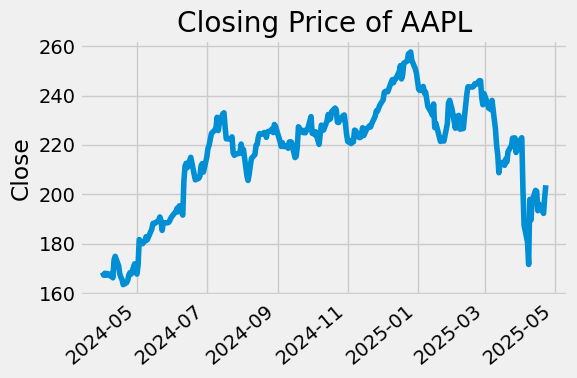

In [14]:
plt.figure(figsize=(6, 4))
plt.plot(df_apple.index, df_apple["Close"])
plt.title("Closing Price of AAPL")
plt.ylabel("Close")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

### Day Moving Averages

The paper says it uses **10-day**, **20-day**, and **50-day** moving averages.

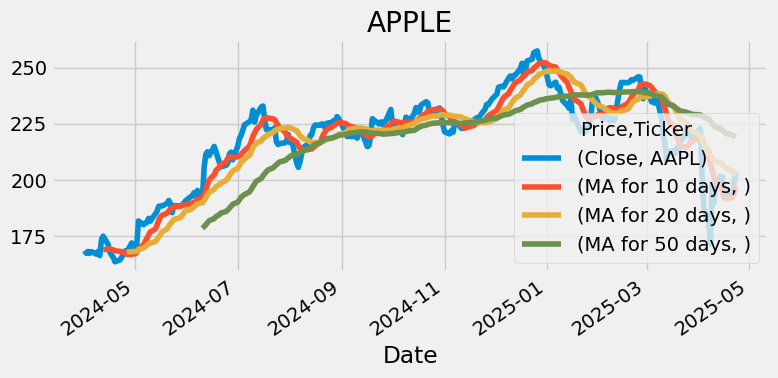

In [15]:
df_apple["MA10"] = df_apple["Close"].rolling(window=10).mean()
df_apple["MA20"] = df_apple["Close"].rolling(window=20).mean()
df_apple["MA50"] = df_apple["Close"].rolling(window=50).mean()

plt.figure(figsize=(8, 4))
plt.plot(df_apple.index, df_apple["Close"], label="(Close, AAPL)")
plt.plot(df_apple.index, df_apple["MA10"], label="(MA for 10 days, )")
plt.plot(df_apple.index, df_apple["MA20"], label="(MA for 20 days, )")
plt.plot(df_apple.index, df_apple["MA50"], label="(MA for 50 days, )")
plt.title("APPLE")
plt.xlabel("Date")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Price,Ticker")
plt.tight_layout()
plt.show()

### Daily Returns

The paper defines daily return as the percent change from one trading day to the next.

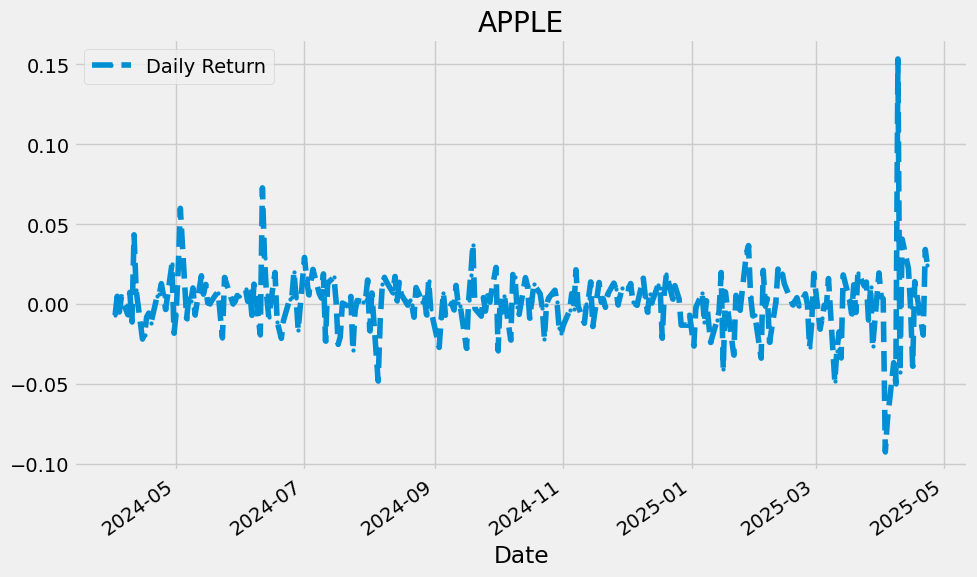

In [16]:
df_apple["Daily Return"] = df_apple["Close"].pct_change()

plt.figure(figsize=(10, 6))
plt.plot(
    df_apple.index,
    df_apple["Daily Return"],
    label="Daily Return",
    linestyle="--",
    marker="o",
    markersize=2
)
plt.title("APPLE")
plt.xlabel("Date")
plt.xticks(rotation=35, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

### Daily Return Distribution

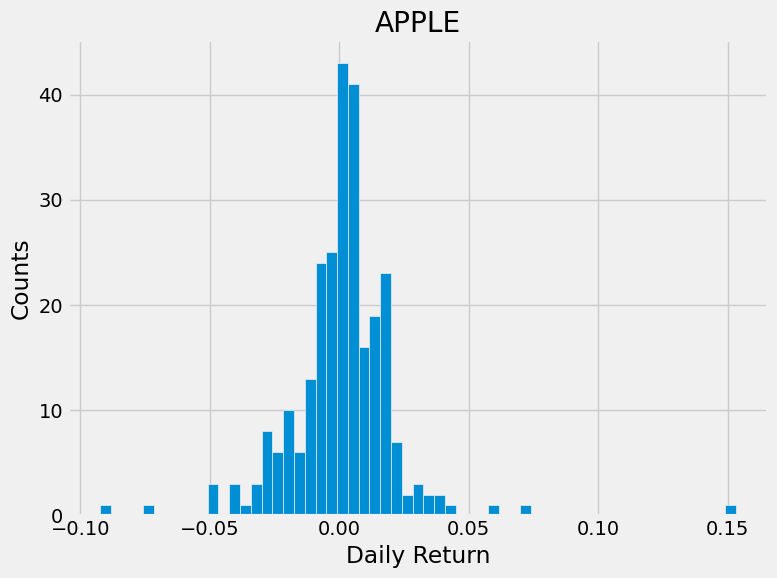

In [17]:
plt.figure(figsize=(8, 6))
sns.histplot(df_apple["Daily Return"].dropna(), bins=59, alpha=1)
plt.title("APPLE")
plt.xlabel("Daily Return")
plt.ylabel("Counts")
plt.tight_layout()
plt.show()

## Simple Risk and Return Summary

In [18]:
print(f"Average daily return is {df_apple['Daily Return'].mean()}")
print(f"Risk is {df_apple['Daily Return'].std()}")

Average daily return is 0.0009168930629667855
Risk is 0.020314478692514806


## Modeling Data

### Close Data

In [19]:
close_data = df_apple[["Close"]].copy()
display(close_data.head())
print(close_data.shape)

closing_prices = close_data.values.reshape(-1, 1)

,Close
Date,
2024-04-01,168.496506
2024-04-02,167.317276
2024-04-03,168.119965
2024-04-04,167.297455
2024-04-05,168.050613


(267, 1)


### Sentiment Analyzer

The paper says sentiment came from financial news and social media, but the original dataset is not shared.

To keep this notebook aligned with the **code appendix** and Ethan's sandbox, this notebook uses the same placeholder text:

`"Sample news article text"`

That creates a single sentiment score and repeats it across all days.  
This is useful for reproducing the **pipeline**, but it is also one major reason the final Apple metrics may not match the paper.

In [20]:
analyzer = SentimentIntensityAnalyzer()

news_data = ["Sample news article text"]
sentiments = [analyzer.polarity_scores(text)["compound"] for text in news_data]
sentiments = np.array(sentiments).reshape(-1, 1)

# repeat the single placeholder sentiment score to match the number of trading days
sentiments = np.repeat(sentiments, len(closing_prices)).reshape(-1, 1)

print(f"Closing prices shape is {closing_prices.shape}")
print(f"Sentiments shape is {sentiments.shape}")
print(f"Sentiment score used for all days is {sentiments[0][0]}")

Closing prices shape is (267, 1)
Sentiments shape is (267, 1)
Sentiment score used for all days is 0.0


### Normalize Prices and Sentiments

In [21]:
price_scaler = MinMaxScaler()
sentiment_scaler = MinMaxScaler()

scaled_prices = price_scaler.fit_transform(closing_prices)
scaled_sentiments = sentiment_scaler.fit_transform(sentiments)

scaled_df = pd.DataFrame(
    {
        "Scaled Price": scaled_prices.flatten(),
        "Scaled Sentiment": scaled_sentiments.flatten()
    },
    index=close_data.index
)

display(scaled_df.head())
print(scaled_df.shape)

,Scaled Price,Scaled Sentiment
Date,,
2024-04-01,0.052971,0.0
2024-04-02,0.040439,0.0
2024-04-03,0.048970,0.0
2024-04-04,0.040229,0.0
2024-04-05,0.048233,0.0


(267, 2)


### Build 60 Day Sequences

In [22]:
window_size = 60

X, y = [], []

for i in range(window_size, len(scaled_prices)):
    X.append(
        np.column_stack(
            (
                scaled_prices[i - window_size:i, 0],
                scaled_sentiments[i - window_size:i, 0]
            )
        )
    )
    y.append(scaled_prices[i, 0])

X = np.array(X)
y = np.array(y)

print(f"X shape is {X.shape}")
print(f"y shape is {y.shape}")
print(f"One sample shape is {X[0].shape}")

X shape is (207, 60, 2)
y shape is (207,)
One sample shape is (60, 2)


### Train Test Split

The paper says it uses an **80/20 split**.

In [23]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"X_train shape {X_train.shape}")
print(f"X_test shape {X_test.shape}")
print(f"y_train shape {y_train.shape}")
print(f"y_test shape {y_test.shape}")

X_train shape (165, 60, 2)
X_test shape (42, 60, 2)
y_train shape (165,)
y_test shape (42,)


### LSTM Model

This follows the architecture described in the paper and mirrored in Ethan's notebook:

- `LSTM(64, return_sequences=True)`
- `Dropout(0.2)`
- `LSTM(32)`
- `Dense(1)`
- optimizer = `"adam"`
- loss = `"mse"`

In [24]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(window_size, 2)))
model.add(Dropout(0.2))
model.add(LSTM(32))
model.add(Dense(1))
model.compile(optimizer="adam", loss="mse")

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │          17,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,601 (115.63 KB)

 Trainable params: 29,601 (115.63 KB)

 Non-trainable params: 0 (0.00 B)

### Train the Model

The paper says the model was trained for **100 epochs** with **batch size 32**.

In [25]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.3237
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0279
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0277
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0120
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0083
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0090
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0080
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0060
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0055
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0068
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0063
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0056
Epoch 13/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0060
Epoch 14/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0056
Epoch 15/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0062
Epoch 16/100
6/6 ━━

### Training Loss

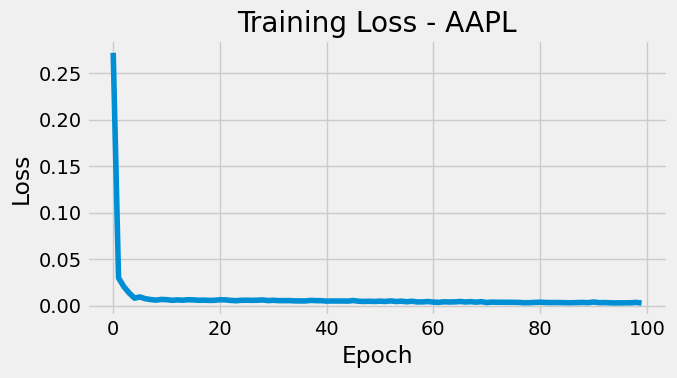

In [26]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"])
plt.title("Training Loss - AAPL")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

### Make Predictions

In [27]:
predictions = model.predict(X_test)

predictions = price_scaler.inverse_transform(predictions)
y_test_actual = price_scaler.inverse_transform(y_test.reshape(-1, 1))

print(f"Predictions shape is {predictions.shape}")
print(f"Actual values shape is {y_test_actual.shape}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
Predictions shape is (42, 1)
Actual values shape is (42, 1)


### Plot Predictions vs Actual

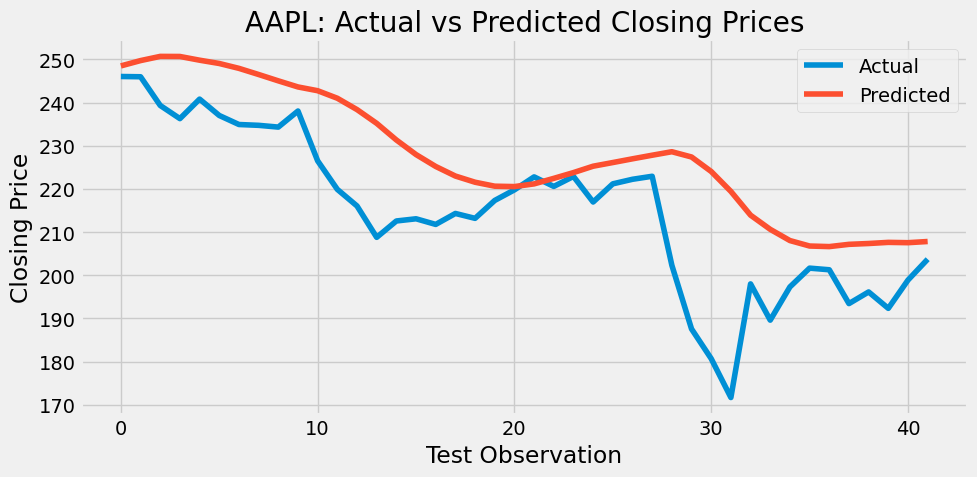

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(y_test_actual, label="Actual")
plt.plot(predictions, label="Predicted")
plt.title("AAPL: Actual vs Predicted Closing Prices")
plt.xlabel("Test Observation")
plt.ylabel("Closing Price")
plt.legend()
plt.tight_layout()
plt.show()

### Evaluate Model

In [29]:
mae = np.mean(np.abs(predictions - y_test_actual))
mse = np.mean((predictions - y_test_actual) ** 2)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}%")

MAE: 12.9504
MSE: 284.2601
RMSE: 16.8600
MAPE: 6.3495%


## Comparison

In [31]:
comparison_df = pd.DataFrame(
    {
        "Metric": ["MAE", "MSE", "RMSE", "MAPE"],
        "Paper Apple": [6.12, 58.03, 7.62, 2.72],
        "My Apple": [mae, mse, rmse, mape]
    }
)

comparison_df["Difference"] = comparison_df["My Apple"] - comparison_df["Paper Apple"]
display(comparison_df)

,Metric,Paper Apple,My Apple,Difference
0,MAE,6.12,12.950431,6.830431
1,MSE,58.03,284.260062,226.230062
2,RMSE,7.62,16.860014,9.240014
3,MAPE,2.72,6.349546,3.629546
